# NLP Final Task 2026 — RAG-Based E-commerce Support Chatbot
## Modules 1 & 2: Language Detection and Sentiment / Emotion Classification

This notebook covers **only the first two modules** of the full four-stage pipeline
(Language Detection → Sentiment/Emotion → Intent Classification → Q&A RAG), as scoped
for this stage of the project. Intent classification and RAG (module 3 & 4) are noted
as future work at the end of this notebook but are **not implemented here**.

**Structure**
1. Setup & Imports
2. Load the Datasets
3. Planning (MoE? Arabic? Where does BERT fit?)
4. Module 1 — Language Detection
5. Module 2 — Sentiment / Emotion Classification
6. Overall Comparison & Revisiting the Planning Questions
7. Next Steps (out of scope for this notebook)
8. Reproducibility Notes

**Recommended runtime:** Google Colab / Kaggle with a GPU, for the transformer
fine-tuning cells (Sections 4.6 and 5.6). Everything else runs fine on CPU.

## 1. Setup & Imports

In [1]:
# Colab/Kaggle already ship torch, scikit-learn, pandas, numpy, matplotlib, seaborn.
# These are the ones that typically need installing:
!pip install -q datasets transformers evaluate accelerate emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.9 MB/s eta 0:00:00


In [2]:
import os
import re
import random
import unicodedata
import warnings
from dataclasses import dataclass
from collections import Counter
from typing import List, Dict, Tuple, Optional

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset, DatasetDict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline as hf_pipeline,
)
import evaluate

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
@dataclass
class LangIDConfig:
    dataset_name: str = "papluca/language-identification"
    tfidf_char_ngrams: Tuple[int, int] = (1, 4)
    tfidf_max_features: int = 60_000
    bert_checkpoint: str = "distilbert-base-multilingual-cased"
    bert_max_length: int = 64
    bert_epochs: int = 2
    bert_batch_size: int = 32
    bert_lr: float = 3e-5
    # 70k training rows over 20 classes is heavy to fine-tune in a classroom
    # setting -- subsample for the transformer run, use the full set for the
    # classical models (which are cheap). Set to None to use all 70k rows.
    bert_train_subsample: Optional[int] = 20_000


@dataclass
class EmotionConfig:
    dataset_name: str = "dair-ai/emotion"
    dataset_config: str = "split"
    max_vocab_size: int = 20_000
    max_seq_len: int = 40
    embed_dim: int = 128
    hidden_dim: int = 128
    lstm_epochs: int = 8
    lstm_batch_size: int = 64
    lstm_lr: float = 1e-3
    bert_checkpoint: str = "bert-base-uncased"
    bert_max_length: int = 64
    bert_epochs: int = 3
    bert_batch_size: int = 32
    bert_lr: float = 2e-5


lang_cfg = LangIDConfig()
emo_cfg = EmotionConfig()

### Shared utilities

Both modules eventually fine-tune a Hugging Face transformer, so that logic is
written **once** here and reused in Sections 4.6 and 5.6, instead of being
duplicated per module.

In [4]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    """Generic accuracy + macro-F1 for any Hugging Face Trainer classification run."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }


def finetune_transformer(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    text_col: str,
    label_col: str,
    class_names: List[str],
    checkpoint: str,
    output_dir: str,
    max_length: int = 64,
    epochs: int = 3,
    batch_size: int = 32,
    lr: float = 2e-5,
    train_subsample: Optional[int] = None,
) -> Tuple[Trainer, Dict[str, float]]:
    """Fine-tune a Hugging Face sequence-classification checkpoint.

    Returns the fitted `Trainer` (so its `.model` / `.tokenizer` can be reused
    for inference later) and the metrics dict from evaluating on `test_df`.
    """
    label2id = {c: i for i, c in enumerate(class_names)}
    id2label = {i: c for c, i in label2id.items()}

    def prep(df: pd.DataFrame) -> pd.DataFrame:
        out = df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"}).copy()
        out["label"] = out["label"].map(label2id)
        return out

    train_pd, val_pd, test_pd = prep(train_df), prep(val_df), prep(test_df)
    if train_subsample:
        train_pd = train_pd.sample(n=min(train_subsample, len(train_pd)), random_state=SEED)

    ds = DatasetDict(
        train=Dataset.from_pandas(train_pd.reset_index(drop=True)),
        validation=Dataset.from_pandas(val_pd.reset_index(drop=True)),
        test=Dataset.from_pandas(test_pd.reset_index(drop=True)),
    )

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    tok_ds = ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=max_length), batched=True)
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=len(class_names), id2label=id2label, label2id=label2id
    )

    args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        eval_strategy="epoch",   # older `transformers` (<4.41): use `evaluation_strategy` instead
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        seed=SEED,
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tok_ds["train"],
        eval_dataset=tok_ds["validation"],
        processing_class=tokenizer,
        data_collator=collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    test_metrics = trainer.evaluate(tok_ds["test"])
    return trainer, test_metrics

## 2. Load the Datasets

### 2.1 Language Identification dataset — `papluca/language-identification`

90k samples total across 20 languages, pre-split train/validation/test, perfectly
class-balanced (3500/lang in train, 500/lang in validation and test).

In [5]:
raw_lang = load_dataset(lang_cfg.dataset_name)
print(raw_lang)

# The dataset card's prose calls the splits "train, valid, and test" -- guard
# against the split key being "valid" instead of "validation" rather than
# hardcoding an assumption.
val_key = "validation" if "validation" in raw_lang else "valid"

lang_train = raw_lang["train"].to_pandas().rename(columns={"labels": "language"})
lang_val = raw_lang[val_key].to_pandas().rename(columns={"labels": "language"})
lang_test = raw_lang["test"].to_pandas().rename(columns={"labels": "language"})

print(f"train={lang_train.shape}, val={lang_val.shape}, test={lang_test.shape}")
print(f"languages: {sorted(lang_train['language'].unique())}")
lang_train.head()

README.md:   0%|          | 0.00/4.99k [00:00<?, ?B/s]

train.csv: reconstructing file:   0%|          |  0.00B / 12.0MB            

train.csv: downloading bytes:           |  0.00B            

valid.csv:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})
train=(70000, 2), val=(10000, 2), test=(10000, 2)
languages: ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


,language,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


### 2.2 Sentiment / Emotion dataset — `dair-ai/emotion`

~20k English tweets labeled with 6 emotions. We use the `"split"` config, which
ships an official 16k/2k/2k train/validation/test split (the alternative,
`"unsplit"`, is a single 417k-row pool with no splits and is not used here).

In [6]:
raw_emotion = load_dataset(emo_cfg.dataset_name, emo_cfg.dataset_config)
print(raw_emotion)

EMOTION_LABELS = raw_emotion["train"].features["label"].names
print("6-class labels:", EMOTION_LABELS)

emo_train = raw_emotion["train"].to_pandas()
emo_val = raw_emotion["validation"].to_pandas()
emo_test = raw_emotion["test"].to_pandas()

for df in (emo_train, emo_val, emo_test):
    df["emotion"] = df["label"].map(lambda i: EMOTION_LABELS[i])

print(f"train={emo_train.shape}, val={emo_val.shape}, test={emo_test.shape}")
emo_train.head()

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
6-class labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
train=(16000, 3), val=(2000, 3), test=(2000, 3)


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## 3. Planning

### 3.1 Where these two modules sit in the pipeline

Every customer message will eventually pass through four stages: **Language
Detection → Sentiment/Emotion → Intent Classification → Q&A RAG**. This
notebook builds the first two, which are both single-label text-classification
problems with off-the-shelf labeled data, so they're a natural pair to build
and compare together before intent classification and RAG (which need the
Bitext dataset) are tackled separately.

### 3.2 Is a Mixture-of-Experts (MoE) architecture needed?

**Short answer: no** — not as a neural-network-internal architecture (sparsely
gated expert layers, à la Switch Transformer / Mixtral). The system already
*is* a mixture-of-experts at the pipeline level — four specialized, independently
trained classifiers, each an "expert" for one sub-task — and that is the right
level to put this idea at for a project of this scale. Reasons:

- **Scale mismatch.** Internal MoE layers exist to add model capacity without a
  proportional compute increase, and they pay off with huge parameter budgets and
  huge, diverse training corpora. Here each sub-task is narrow — 20 language
  classes or 6/3 emotion classes, on 20k–90k labeled rows. A single BERT-sized
  encoder already has more capacity than these tasks need; the bottleneck is
  data and label quality, not model capacity.
- **Cheap baselines are already close to ceiling.** Published model cards for
  this exact language-ID dataset report a plain pretrained `langid.py` baseline
  reaching roughly 98.5% test accuracy, with a fully fine-tuned XLM-RoBERTa
  reaching about 99.6% — a gap of about one point for a much heavier model.
  Community BERT-family fine-tunes on `dair-ai/emotion` commonly land around
  92–93% test accuracy. When a cheap classical/linear baseline is already this
  close to a heavy transformer, spending complexity budget on internal MoE
  routing for the last fraction of a point is a poor trade, especially for a
  latency-sensitive, real-time support chatbot.
- **Latency and explainability.** This pipeline runs on every incoming message.
  A sequence of small, specialized, independently retrainable and auditable
  models is easier to monitor and debug ("why did this message get flagged
  urgent?") than a single large model with an internal soft router you can't
  easily inspect.
- **Where MoE *would* make sense:** if a later phase serves one large shared
  generation model across many verticals/languages for the RAG-answering step,
  a MoE decoder could be worth it purely for compute-efficient scaling of that
  one large model. That is a different problem (large-scale generation) than
  the small classification/retrieval stages this notebook covers.

**Conclusion:** keep the pipeline's system-level "mixture of experts" (four
specialized modules); skip model-internal MoE layers inside each classifier.

### 3.3 Handling Arabic

Arabic (`ar`) is one of the 20 languages in `papluca/language-identification`.
The Bitext knowledge base used later for intent/RAG is English-only, so Arabic
support splits into two different problems: **detecting** Arabic (this
notebook, Module 1) and **serving** an Arabic-speaking customer end-to-end
(Modules 3–4, out of scope here).

**Detection (this notebook):**
- Arabic occupies its own Unicode block, so it is one of the most reliably
  separable languages in a script-aware model — a character n-gram signal
  should isolate it almost perfectly without any special-casing.
- Preprocessing must not apply Latin-oriented steps to Arabic text: no
  case-folding (Arabic has no letter case), and diacritics (tashkeel) should
  not be aggressively stripped, since that same step would also damage
  accented characters in other languages. Unicode NFKC normalization (applied
  below) unifies visually-equivalent character forms without a
  language-specific branch.
- The one place real ambiguity could appear is Arabic vs. Urdu (`ur`), since
  Urdu is also written in a Perso-Arabic script — the confusion matrix and
  per-language report in Section 4.5 check this directly.

**Serving Arabic-speaking customers (flagged for Modules 3/4, not built here):**
- Once Module 1 flags a message as Arabic, the system needs either (a) a
  translation layer (Arabic → English → retrieve/respond → English → Arabic),
  or (b) an Arabic-aware embedding model (e.g. AraBERT, CAMeLBERT, or a
  multilingual sentence encoder) plus either a translated knowledge base or an
  Arabic-capable generator — an English-tuned embedding space shouldn't be
  force-fit to Arabic queries.
- An English-only tokenizer (e.g. `bert-base-uncased`) doesn't cover Arabic
  subwords well, so any Arabic-aware downstream step needs a multilingual or
  Arabic-native tokenizer.
- Product-level note (not an NLP concern, but worth flagging): Arabic is
  right-to-left, so any UI rendering Arabic responses needs RTL support.

For this notebook's scope, the practical deliverable is: verify Module 1
detects `ar` reliably, and treat a correct Arabic detection as the hand-off
signal to whichever translation-or-multilingual strategy Modules 3–4 adopt.

### 3.4 Where does BERT actually help?

- **Module 1 (language ID):** not expected to meaningfully beat a well-tuned
  character n-gram TF-IDF + linear classifier, because language ID is
  fundamentally a surface-statistics problem (character/script distribution) —
  exactly what n-gram counting already captures. We fine-tune a small
  multilingual transformer anyway, purely to measure the gap empirically
  (Section 4.6): expect it to land close to, not dramatically above, the
  classical pipeline, at much higher training/inference cost.
- **Module 2 (emotion/sentiment):** this is where BERT should earn its cost.
  Telling "fear" apart from "sadness," or "joy" from "love," in a short tweet
  needs contextual/semantic understanding that bag-of-words TF-IDF and even a
  from-scratch-embedding BiLSTM struggle with on a relatively small training
  set (16k rows across 6 classes, several of them minority classes). BERT's
  pretrained representations should give a measurable macro-F1 boost here,
  especially on `love` and `surprise` — this is checked directly in Section 5.8.

## 4. Module 1 — Language Detection

### 4.1 Exploratory Data Analysis

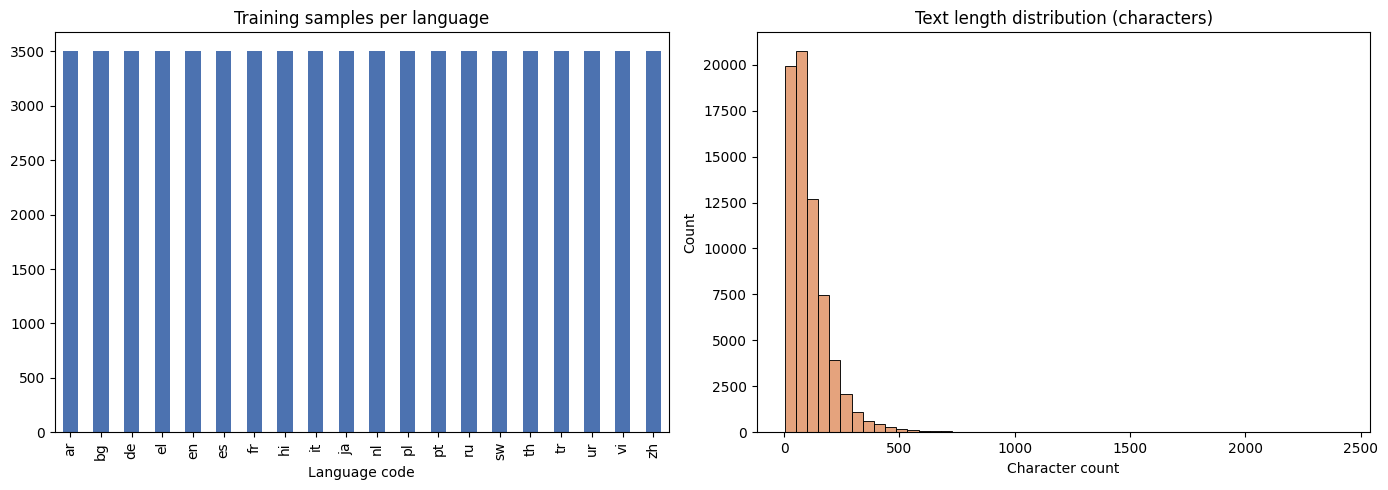

Languages (20): ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']
Median text length: 82 characters


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lang_train["language"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Training samples per language")
axes[0].set_xlabel("Language code")

lang_train["char_len"] = lang_train["text"].str.len()
sns.histplot(lang_train["char_len"], bins=50, ax=axes[1], color="#DD8452")
axes[1].set_title("Text length distribution (characters)")
axes[1].set_xlabel("Character count")

plt.tight_layout()
plt.show()

print(f"Languages ({lang_train['language'].nunique()}): {sorted(lang_train['language'].unique())}")
print(f"Median text length: {lang_train['char_len'].median():.0f} characters")

### 4.2 Preprocessing

In [8]:
_URL_RE = re.compile(r"https?://\S+|www\.\S+")
_WS_RE = re.compile(r"\s+")


def clean_for_language_id(text: str) -> str:
    """Minimal, script-preserving cleaning for language identification.

    Design choice: language ID relies on surface-level statistical signal
    (character/script distribution, short function words, diacritics), so we
    deliberately do NOT strip accents, punctuation, or digits, and we do NOT
    stem/lemmatize -- all of that would destroy the very signal the model
    needs. We only remove clearly non-linguistic noise (URLs) and normalize
    whitespace and unicode form so visually-identical characters don't
    fragment the vocabulary (NFKC normalization).
    """
    text = unicodedata.normalize("NFKC", text)
    text = _URL_RE.sub(" ", text)
    text = _WS_RE.sub(" ", text).strip()
    return text.lower()


for df in (lang_train, lang_val, lang_test):
    df["clean_text"] = df["text"].map(clean_for_language_id)

lang_train[["text", "clean_text", "language"]].sample(5, random_state=SEED)

,text,clean_text,language
46730,Hab für den Preis mehr erwartet.,hab für den preis mehr erwartet.,de
48393,"Письмо в письменном виде убийцы , друзья мои !","письмо в письменном виде убийцы , друзья мои !",ru
41416,जापानियों ने रैंकिंग दृश ् य और स ् थानों के प...,जापानियों ने रैंकिंग दृश ् य और स ् थानों के प...,hi
34506,"وفي عام 1853 , كان القصد من قصر دولما - bahce ...","وفي عام 1853 , كان القصد من قصر دولما - bahce ...",ar
43725,"Các nhà chức trách y tế anh , trong 1995 nguyê...","các nhà chức trách y tế anh , trong 1995 nguyê...",vi


### 4.3 Baseline — word-level TF-IDF + Logistic Regression

In [9]:
X_train, y_train = lang_train["clean_text"], lang_train["language"]
X_val, y_val = lang_val["clean_text"], lang_val["language"]
X_test, y_test = lang_test["clean_text"], lang_test["language"]

word_tfidf = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), max_features=lang_cfg.tfidf_max_features)
Xw_train = word_tfidf.fit_transform(X_train)
Xw_val = word_tfidf.transform(X_val)
Xw_test = word_tfidf.transform(X_test)

word_clf = LogisticRegression(max_iter=1000, n_jobs=-1)
word_clf.fit(Xw_train, y_train)

word_val_acc = accuracy_score(y_val, word_clf.predict(Xw_val))
word_test_acc = accuracy_score(y_test, word_clf.predict(Xw_test))
print(f"[Baseline] word TF-IDF + LogisticRegression -- val acc: {word_val_acc:.4f} | test acc: {word_test_acc:.4f}")

[Baseline] word TF-IDF + LogisticRegression -- val acc: 0.9116 | test acc: 0.9139


### 4.4 Enhancement — character n-gram TF-IDF, model selection, and tuning

Word-level features struggle with short function words and don't generalise
well across languages sharing vocabulary roots. Character n-grams (within word
boundaries, `char_wb`) capture sub-word and script-level patterns, which is
the standard, much stronger representation for language ID. We compare three
linear/probabilistic classifiers on top of it.

In [10]:
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=lang_cfg.tfidf_char_ngrams,
    max_features=lang_cfg.tfidf_max_features,
    sublinear_tf=True,
)
Xc_train = char_tfidf.fit_transform(X_train)
Xc_val = char_tfidf.transform(X_val)
Xc_test = char_tfidf.transform(X_test)

candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "LinearSVC": LinearSVC(),
    "ComplementNB": ComplementNB(),
}

char_val_results = {}
for name, clf in candidates.items():
    clf.fit(Xc_train, y_train)
    val_acc = accuracy_score(y_val, clf.predict(Xc_val))
    char_val_results[name] = val_acc
    print(f"[char n-gram TF-IDF] {name:<20s} val accuracy: {val_acc:.4f}")

best_name = max(char_val_results, key=char_val_results.get)
print(f"\nBest classical model on validation: {best_name} ({char_val_results[best_name]:.4f})")

[char n-gram TF-IDF] LogisticRegression   val accuracy: 0.9948
[char n-gram TF-IDF] LinearSVC            val accuracy: 0.9954
[char n-gram TF-IDF] ComplementNB         val accuracy: 0.9931

Best classical model on validation: LinearSVC (0.9954)


In [11]:
# Light hyperparameter search around the winning classical model.
if best_name == "LinearSVC":
    param_grid = {"C": [0.1, 0.5, 1.0, 2.0]}
elif best_name == "LogisticRegression":
    param_grid = {"C": [0.5, 1.0, 2.0, 5.0]}
else:
    param_grid = {"alpha": [0.1, 0.5, 1.0]}

grid = GridSearchCV(candidates[best_name], param_grid, cv=3, scoring="accuracy", n_jobs=-1)
grid.fit(Xc_train, y_train)
print("Best params:", grid.best_params_)

tuned_clf = grid.best_estimator_
tuned_val_acc = accuracy_score(y_val, tuned_clf.predict(Xc_val))
tuned_test_acc = accuracy_score(y_test, tuned_clf.predict(Xc_test))
print(f"Tuned {best_name} (char n-grams) -- val acc: {tuned_val_acc:.4f} | test acc: {tuned_test_acc:.4f}")

Best params: {'C': 0.5}
Tuned LinearSVC (char n-grams) -- val acc: 0.9953 | test acc: 0.9955


### 4.5 Error Analysis (with an Arabic/Urdu callout, per the planning notes)

              precision    recall  f1-score   support

          ar      1.000     0.998     0.999       500
          bg      0.998     1.000     0.999       500
          de      1.000     1.000     1.000       500
          el      1.000     1.000     1.000       500
          en      0.996     1.000     0.998       500
          es      0.994     0.998     0.996       500
          fr      1.000     1.000     1.000       500
          hi      1.000     0.968     0.984       500
          it      0.996     0.998     0.997       500
          ja      1.000     1.000     1.000       500
          nl      0.996     0.998     0.997       500
          pl      1.000     0.998     0.999       500
          pt      0.992     0.994     0.993       500
          ru      1.000     0.998     0.999       500
          sw      0.945     0.996     0.970       500
          th      1.000     1.000     1.000       500
          tr      0.996     1.000     0.998       500
          ur      1.000    

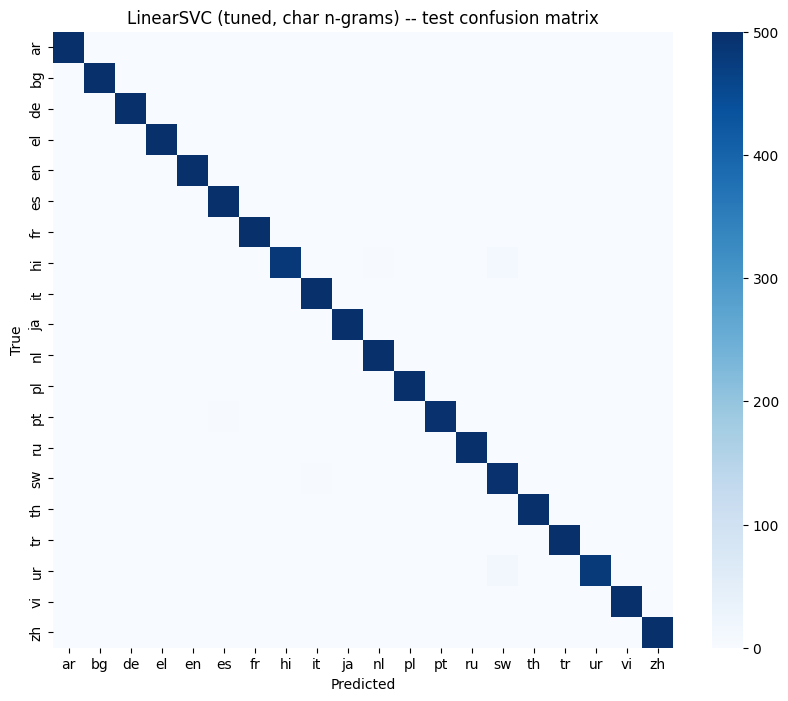

ar predicted as ur: 0 / 500 Arabic test examples
ur predicted as ar: 0 / 500 Urdu test examples


In [12]:
test_preds = tuned_clf.predict(Xc_test)
print(classification_report(y_test, test_preds, digits=3))

labels_sorted = sorted(y_test.unique())
cm = confusion_matrix(y_test, test_preds, labels=labels_sorted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"{best_name} (tuned, char n-grams) -- test confusion matrix")
plt.show()

# Per the Arabic planning note: check confusion specifically between Arabic (ar)
# and the other Perso-Arabic-script language in the label set, Urdu (ur).
if "ar" in labels_sorted and "ur" in labels_sorted:
    i_ar, i_ur = labels_sorted.index("ar"), labels_sorted.index("ur")
    print(f"ar predicted as ur: {cm[i_ar, i_ur]} / {cm[i_ar].sum()} Arabic test examples")
    print(f"ur predicted as ar: {cm[i_ur, i_ar]} / {cm[i_ur].sum()} Urdu test examples")

### 4.6 Transformer comparison (multilingual BERT-family)

Per Section 3.4, this is expected to land close to, not far above, the tuned
classical model. We fine-tune a lightweight multilingual checkpoint
(`distilbert-base-multilingual-cased`) using the shared `finetune_transformer`
helper from Section 1, on a subsample of the training set to keep this
tractable on a single GPU.

In [13]:
lang_class_names = sorted(lang_train["language"].unique())

lang_trainer, lang_bert_test_metrics = finetune_transformer(
    lang_train, lang_val, lang_test,
    text_col="clean_text", label_col="language", class_names=lang_class_names,
    checkpoint=lang_cfg.bert_checkpoint, output_dir="./lang_id_bert",
    max_length=lang_cfg.bert_max_length, epochs=lang_cfg.bert_epochs,
    batch_size=lang_cfg.bert_batch_size, lr=lang_cfg.bert_lr,
    train_subsample=lang_cfg.bert_train_subsample,
)
print(lang_bert_test_metrics)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.025216,0.072519,0.986100,0.986262
2,0.007757,0.071375,0.986300,0.986471


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.007757,0.053867,2,0.990700,0.990818


{'eval_loss': 0.053867485374212265, 'eval_accuracy': 0.9907, 'eval_f1_macro': 0.9908184743254285}


### 4.7 Module 1 — Results & Takeaways

In [14]:
lang_results_table = pd.DataFrame([
    {"Model": "Word TF-IDF + LogisticRegression", "Features": "word 1-2gram",
     "Val Acc": word_val_acc, "Test Acc": word_test_acc},
    {"Model": f"Char n-gram TF-IDF + {best_name} (tuned)", "Features": f"char_wb {lang_cfg.tfidf_char_ngrams}",
     "Val Acc": tuned_val_acc, "Test Acc": tuned_test_acc},
    {"Model": lang_cfg.bert_checkpoint, "Features": "subword + context",
     "Val Acc": lang_bert_test_metrics.get("eval_accuracy"), "Test Acc": lang_bert_test_metrics.get("eval_accuracy")},
])
lang_results_table

,Model,Features,Val Acc,Test Acc
0,Word TF-IDF + LogisticRegression,word 1-2gram,0.9116,0.9139
1,Char n-gram TF-IDF + LinearSVC (tuned),"char_wb (1, 4)",0.9953,0.9955
2,distilbert-base-multilingual-cased,subword + context,0.9907,0.9907


**Read this table once the cells above have actually run.** The expectation
from Section 3.4 is: word TF-IDF < char n-gram TF-IDF ≈ multilingual BERT,
with the transformer costing far more to train/serve for little to no extra
accuracy — supporting the choice to keep language ID on the cheap classical
path in production and reserve the compute budget for Module 2, where a
transformer is expected to actually move the needle.

## 5. Module 2 — Sentiment / Emotion Classification

### 5.1 Exploratory Data Analysis

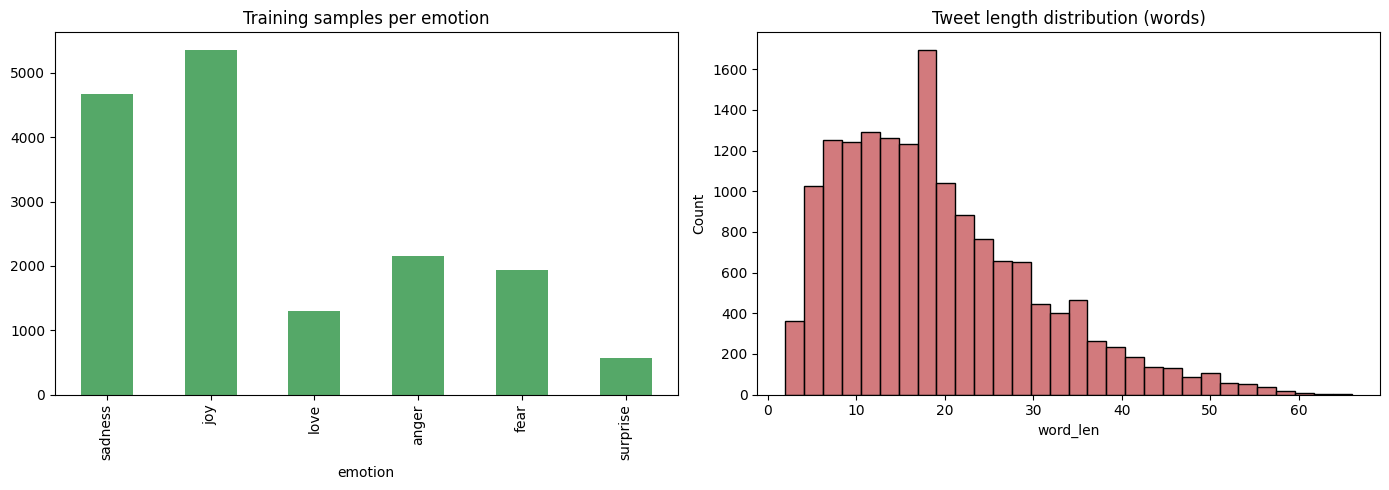

,proportion
emotion,
joy,0.335
sadness,0.292
anger,0.135
fear,0.121
love,0.082
surprise,0.036


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emo_train["emotion"].value_counts().reindex(EMOTION_LABELS).plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("Training samples per emotion")

emo_train["word_len"] = emo_train["text"].str.split().apply(len)
sns.histplot(emo_train["word_len"], bins=30, ax=axes[1], color="#C44E52")
axes[1].set_title("Tweet length distribution (words)")

plt.tight_layout()
plt.show()

emo_train["emotion"].value_counts(normalize=True).round(3)

### 5.2 Mapping 6 emotions → 3 sentiment buckets

The task asks for an optional 3-bucket (negative/neutral/positive) view for a
simpler routing signal. `dair-ai/emotion` has no inherently neutral class, so
this mapping is a design choice, not a given:

- **negative:** sadness, anger, fear — all clearly unpleasant, all should
  trigger a more apologetic/urgent response path.
- **positive:** joy, love — both clearly pleasant.
- **neutral:** surprise — the one genuinely ambiguous emotion (it can be
  pleasant *or* unpleasant depending on context, and the text alone doesn't
  disambiguate that). It is also the smallest class in this dataset, so the
  resulting "neutral" bucket will be under-represented — we use
  `class_weight="balanced"` / weighted loss throughout Module 2 to compensate,
  rather than pretending the imbalance isn't there.

In [16]:
BUCKET_MAP = {
    "sadness": "negative",
    "anger": "negative",
    "fear": "negative",
    "joy": "positive",
    "love": "positive",
    "surprise": "neutral",
}
BUCKET_LABELS = ["negative", "neutral", "positive"]

for df in (emo_train, emo_val, emo_test):
    df["sentiment"] = df["emotion"].map(BUCKET_MAP)

print(emo_train["sentiment"].value_counts(normalize=True).round(3))

sentiment
negative    0.548
positive    0.417
neutral     0.036
Name: proportion, dtype: float64


### 5.3 Preprocessing

Unlike language ID, here the *content words* carry the signal, so we can
afford to be more aggressive. Two variants are produced:

- `clean_text` — heavier cleaning (lowercased, emoji-demojized, handles/URLs/
  hashmarks stripped, letter-elongation collapsed, punctuation removed) for
  the TF-IDF baseline and the from-scratch-embedding BiLSTM, which have no
  other way to make sense of noisy tokens.
- `bert_text` — a much lighter pass (URLs/handles removed only) for BERT,
  whose WordPiece tokenizer already handles casing and punctuation better
  than a hand-written regex would.

In [17]:
try:
    import emoji as _emoji_lib
    _HAS_EMOJI = True
except ImportError:
    _HAS_EMOJI = False

_MENTION_RE = re.compile(r"@\w+")
_URL_RE2 = re.compile(r"https?://\S+|www\.\S+")
_HASHTAG_RE = re.compile(r"#(\w+)")
_REPEAT_RE = re.compile(r"(.)\1{2,}")
_NON_ALPHA_RE = re.compile(r"[^a-zA-Z\'\s]")
_WS_RE2 = re.compile(r"\s+")


def clean_tweet(text: str) -> str:
    """Heavier, Twitter-oriented cleaning for the TF-IDF baseline and BiLSTM."""
    text = text.lower()
    if _HAS_EMOJI:
        text = _emoji_lib.demojize(text, delimiters=(" ", " "))
    text = _URL_RE2.sub(" ", text)
    text = _MENTION_RE.sub(" ", text)
    text = _HASHTAG_RE.sub(r"\1", text)
    text = _REPEAT_RE.sub(r"\1\1", text)
    text = _NON_ALPHA_RE.sub(" ", text)
    text = _WS_RE2.sub(" ", text).strip()
    return text


def light_clean_for_bert(text: str) -> str:
    """Minimal cleaning for BERT input -- let the WordPiece tokenizer do the rest."""
    text = _URL_RE2.sub(" ", text)
    text = _MENTION_RE.sub(" ", text)
    return _WS_RE2.sub(" ", text).strip()


for df in (emo_train, emo_val, emo_test):
    df["clean_text"] = df["text"].map(clean_tweet)
    df["bert_text"] = df["text"].map(light_clean_for_bert)

emo_train[["text", "clean_text", "bert_text"]].sample(5, random_state=SEED)

,text,clean_text,bert_text
8756,ive made it through a week i just feel beaten ...,ive made it through a week i just feel beaten ...,ive made it through a week i just feel beaten ...
4660,i feel this strategy is worthwhile,i feel this strategy is worthwhile,i feel this strategy is worthwhile
6095,i feel so worthless and weak what does he have...,i feel so worthless and weak what does he have...,i feel so worthless and weak what does he have...
304,i feel clever nov,i feel clever nov,i feel clever nov
8241,im moved in ive been feeling kind of gloomy,im moved in ive been feeling kind of gloomy,im moved in ive been feeling kind of gloomy


### 5.4 Baseline — TF-IDF + Logistic Regression

In [18]:
def evaluate_tfidf_baseline(train_df, val_df, test_df, target_col):
    tfidf = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2))
    Xtr = tfidf.fit_transform(train_df["clean_text"])
    Xva = tfidf.transform(val_df["clean_text"])
    Xte = tfidf.transform(test_df["clean_text"])

    clf = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
    clf.fit(Xtr, train_df[target_col])

    val_acc = accuracy_score(val_df[target_col], clf.predict(Xva))
    test_preds = clf.predict(Xte)
    test_acc = accuracy_score(test_df[target_col], test_preds)
    test_f1 = f1_score(test_df[target_col], test_preds, average="macro")
    return {"val_acc": val_acc, "test_acc": test_acc, "test_f1_macro": test_f1}


baseline_6class = evaluate_tfidf_baseline(emo_train, emo_val, emo_test, "emotion")
baseline_3class = evaluate_tfidf_baseline(emo_train, emo_val, emo_test, "sentiment")
print("TF-IDF + LogisticRegression, 6-class:", baseline_6class)
print("TF-IDF + LogisticRegression, 3-class:", baseline_3class)

TF-IDF + LogisticRegression, 6-class: {'val_acc': 0.877, 'test_acc': 0.8685, 'test_f1_macro': 0.8277318288273304}
TF-IDF + LogisticRegression, 3-class: {'val_acc': 0.93, 'test_acc': 0.9305, 'test_f1_macro': 0.8573618255364073}


### 5.5 RNN — BiLSTM (PyTorch, per the task's "RNN or Transformers" option)

A from-scratch vocabulary and embedding table, trained end-to-end with a
bidirectional LSTM. Class weights compensate for the emotion imbalance noted
in Section 5.2 (and are far more pronounced for `love`/`surprise`).

In [19]:
def build_vocab(token_lists, max_size=20_000, min_freq=2, specials=("<pad>", "<unk>")):
    counter = Counter(tok for toks in token_lists for tok in toks)
    vocab = {tok: i for i, tok in enumerate(specials)}
    for tok, freq in counter.most_common():
        if len(vocab) >= max_size:
            break
        if freq >= min_freq and tok not in vocab:
            vocab[tok] = len(vocab)
    return vocab


def encode(tokens, vocab, max_len):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens[:max_len]]
    ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids


class EmotionDataset(TorchDataset):
    def __init__(self, texts: List[str], labels: np.ndarray, vocab: Dict[str, int], max_len: int):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int):
        ids = encode(self.texts[idx].split(), self.vocab, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, num_classes: int,
                 pad_idx: int = 0, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(x)                          # (B, T, E)
        _, (hidden, _) = self.lstm(embedded)                   # hidden: (2, B, H)
        final = torch.cat([hidden[-2], hidden[-1]], dim=-1)    # concat fwd/bwd final states -> (B, 2H)
        return self.classifier(self.dropout(final))

In [20]:
def train_bilstm(train_df, val_df, test_df, target_col, class_names, cfg: EmotionConfig):
    label2id = {c: i for i, c in enumerate(class_names)}
    y_train = train_df[target_col].map(label2id).values
    y_val = val_df[target_col].map(label2id).values
    y_test = test_df[target_col].map(label2id).values

    vocab = build_vocab(train_df["clean_text"].str.split().tolist(), max_size=cfg.max_vocab_size)

    train_ds = EmotionDataset(train_df["clean_text"].tolist(), y_train, vocab, cfg.max_seq_len)
    val_ds = EmotionDataset(val_df["clean_text"].tolist(), y_val, vocab, cfg.max_seq_len)
    test_ds = EmotionDataset(test_df["clean_text"].tolist(), y_test, vocab, cfg.max_seq_len)

    train_loader = DataLoader(train_ds, batch_size=cfg.lstm_batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.lstm_batch_size)
    test_loader = DataLoader(test_ds, batch_size=cfg.lstm_batch_size)

    class_weights = compute_class_weight("balanced", classes=np.arange(len(class_names)), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    model = BiLSTMClassifier(len(vocab), cfg.embed_dim, cfg.hidden_dim, len(class_names)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lstm_lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    def run_epoch(loader, train: bool):
        model.train() if train else model.eval()
        total_loss, all_preds, all_labels = 0.0, [], []
        with torch.set_grad_enabled(train):
            for x, y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                loss = criterion(logits, y)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * x.size(0)
                all_preds.extend(logits.argmax(-1).cpu().tolist())
                all_labels.extend(y.cpu().tolist())
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average="macro")
        return total_loss / len(loader.dataset), acc, f1

    for epoch in range(1, cfg.lstm_epochs + 1):
        tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
        va_loss, va_acc, va_f1 = run_epoch(val_loader, train=False)
        print(f"epoch {epoch:>2d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} "
              f"| val loss {va_loss:.4f} acc {va_acc:.4f} f1 {va_f1:.4f}")

    _, test_acc, test_f1 = run_epoch(test_loader, train=False)
    return model, {"val_acc": va_acc, "test_acc": test_acc, "test_f1_macro": test_f1}

In [21]:
bilstm_model_6, bilstm_metrics_6 = train_bilstm(emo_train, emo_val, emo_test, "emotion", EMOTION_LABELS, emo_cfg)
print("BiLSTM 6-class:", bilstm_metrics_6)

epoch  1 | train loss 1.6753 acc 0.2270 | val loss 1.3830 acc 0.3875 f1 0.4049
epoch  2 | train loss 1.1210 acc 0.4871 | val loss 0.9782 acc 0.5990 f1 0.5950
epoch  3 | train loss 0.6983 acc 0.7030 | val loss 0.6050 acc 0.7495 f1 0.7482
epoch  4 | train loss 0.4353 acc 0.8261 | val loss 0.4289 acc 0.8545 f1 0.8407
epoch  5 | train loss 0.2997 acc 0.8868 | val loss 0.4059 acc 0.8555 f1 0.8366
epoch  6 | train loss 0.2300 acc 0.9136 | val loss 0.3529 acc 0.8700 f1 0.8515
epoch  7 | train loss 0.1701 acc 0.9329 | val loss 0.3562 acc 0.8885 f1 0.8691
epoch  8 | train loss 0.1244 acc 0.9516 | val loss 0.4000 acc 0.8820 f1 0.8597
BiLSTM 6-class: {'val_acc': 0.882, 'test_acc': 0.866, 'test_f1_macro': 0.8235926732679014}


In [22]:
bilstm_model_3, bilstm_metrics_3 = train_bilstm(emo_train, emo_val, emo_test, "sentiment", BUCKET_LABELS, emo_cfg)
print("BiLSTM 3-class:", bilstm_metrics_3)

epoch  1 | train loss 0.9972 acc 0.5218 | val loss 0.5879 acc 0.7240 f1 0.7107
epoch  2 | train loss 0.4521 acc 0.7970 | val loss 0.3367 acc 0.8755 f1 0.8375
epoch  3 | train loss 0.2593 acc 0.9020 | val loss 0.2340 acc 0.9195 f1 0.8826
epoch  4 | train loss 0.1744 acc 0.9446 | val loss 0.2631 acc 0.9150 f1 0.8683
epoch  5 | train loss 0.2189 acc 0.9071 | val loss 0.2117 acc 0.9200 f1 0.8783
epoch  6 | train loss 0.1171 acc 0.9620 | val loss 0.1973 acc 0.9415 f1 0.8897
epoch  7 | train loss 0.0742 acc 0.9747 | val loss 0.2747 acc 0.9460 f1 0.9039
epoch  8 | train loss 0.0599 acc 0.9799 | val loss 0.2927 acc 0.9500 f1 0.9049
BiLSTM 3-class: {'val_acc': 0.95, 'test_acc': 0.936, 'test_f1_macro': 0.8649636902292565}


### 5.6 Transformer fine-tuning (BERT)

Reuses `finetune_transformer` from Section 1, on the lightly-cleaned
`bert_text` column, for both the 6-class and the 3-class target.

In [23]:
emo_bert_trainer_6, emo_bert_metrics_6 = finetune_transformer(
    emo_train, emo_val, emo_test,
    text_col="bert_text", label_col="emotion", class_names=EMOTION_LABELS,
    checkpoint=emo_cfg.bert_checkpoint, output_dir="./emotion_bert_6class",
    max_length=emo_cfg.bert_max_length, epochs=emo_cfg.bert_epochs,
    batch_size=emo_cfg.bert_batch_size, lr=emo_cfg.bert_lr,
)
print("BERT 6-class:", emo_bert_metrics_6)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.246975,0.218058,0.923000,0.900938
2,0.126778,0.148073,0.939500,0.917423
3,0.089754,0.149060,0.937500,0.910992


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.089754,0.167253,3,0.934500,0.890790


BERT 6-class: {'eval_loss': 0.16725313663482666, 'eval_accuracy': 0.9345, 'eval_f1_macro': 0.8907899765937032}


In [24]:
emo_bert_trainer_3, emo_bert_metrics_3 = finetune_transformer(
    emo_train, emo_val, emo_test,
    text_col="bert_text", label_col="sentiment", class_names=BUCKET_LABELS,
    checkpoint=emo_cfg.bert_checkpoint, output_dir="./emotion_bert_3class",
    max_length=emo_cfg.bert_max_length, epochs=emo_cfg.bert_epochs,
    batch_size=emo_cfg.bert_batch_size, lr=emo_cfg.bert_lr,
)
print("BERT 3-class:", emo_bert_metrics_3)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.106294,0.067824,0.973500,0.938153
2,0.034262,0.069820,0.977500,0.938605
3,0.031949,0.068199,0.978000,0.941722


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.031949,0.070540,3,0.974500,0.899443


BERT 3-class: {'eval_loss': 0.07054033875465393, 'eval_accuracy': 0.9745, 'eval_f1_macro': 0.8994431995451769}


### 5.7 Domain-shift qualitative check

`dair-ai/emotion` is Twitter text, not customer-support text — the task
explicitly flags this domain shift. As a qualitative check (not a training
set), here is a small hand-labeled set of customer-support-style messages.
We run the best available 3-class model (the fine-tuned BERT) on these
**unseen, out-of-domain** examples and see how well a Twitter-trained model
actually generalises to support phrasing.

In [25]:
support_style_samples = [
    ("My order still hasn't arrived after two weeks and nobody is responding to my emails.", "negative"),
    ("This is the third time my package has been delayed, I am extremely frustrated with this service.", "negative"),
    ("I was charged twice for the same order, please refund the duplicate charge immediately.", "negative"),
    ("Can you tell me the estimated delivery date for order #48213?", "neutral"),
    ("I'd like to update the shipping address on my pending order.", "neutral"),
    ("Just checking on the status of my return request submitted last week.", "neutral"),
    ("Thank you so much for resolving my issue so quickly, really appreciate the support!", "positive"),
    ("The replacement item arrived earlier than expected, great service!", "positive"),
    ("Your support agent was incredibly helpful and patient with me today.", "positive"),
    ("I'm not sure why my discount code isn't working at checkout.", "neutral"),
    ("This product broke after two days and customer service isn't responding, very disappointed.", "negative"),
    ("Could you clarify your return policy for international orders?", "neutral"),
    ("Excellent, fast delivery and the product matches the description perfectly.", "positive"),
    ("I've been on hold for 40 minutes, this is unacceptable.", "negative"),
    ("All good now, thanks for the quick fix!", "positive"),
]
support_df = pd.DataFrame(support_style_samples, columns=["text", "gold_sentiment"])

support_classifier = hf_pipeline(
    "text-classification",
    model=emo_bert_trainer_3.model,
tokenizer=getattr(emo_bert_trainer_3, "tokenizer", None) or getattr(emo_bert_trainer_3, "processing_class", None) or AutoTokenizer.from_pretrained(emo_cfg.bert_checkpoint),
    device=0 if torch.cuda.is_available() else -1,
)

support_df["predicted"] = support_df["text"].apply(lambda t: support_classifier(t)[0]["label"])
support_df["correct"] = support_df["predicted"] == support_df["gold_sentiment"]

print(f"Qualitative domain-shift accuracy on {len(support_df)} hand-labeled support messages: "
      f"{support_df['correct'].mean():.2%}")
support_df

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Qualitative domain-shift accuracy on 15 hand-labeled support messages: 66.67%


,text,gold_sentiment,predicted,correct
0,My order still hasn't arrived after two weeks ...,negative,negative,True
1,This is the third time my package has been del...,negative,negative,True
2,"I was charged twice for the same order, please...",negative,negative,True
3,Can you tell me the estimated delivery date fo...,neutral,positive,False
4,I'd like to update the shipping address on my ...,neutral,negative,False
5,Just checking on the status of my return reque...,neutral,positive,False
6,Thank you so much for resolving my issue so qu...,positive,positive,True
7,The replacement item arrived earlier than expe...,positive,positive,True
8,Your support agent was incredibly helpful and ...,positive,positive,True
9,I'm not sure why my discount code isn't workin...,neutral,negative,False


If this qualitative accuracy comes in noticeably below the in-domain test
accuracy from Section 5.6, that gap **is** the domain-shift effect the task
description warned about — Twitter's informal, emoji-and-hashtag-heavy style
doesn't fully match calmer, more formal support phrasing (e.g. "I would like
to request a refund" reads very differently from an angry tweet, even when
the underlying sentiment is similarly negative). A production system would
want either a small amount of support-domain fine-tuning data, or at least
this kind of qualitative monitoring before trusting the routing signal.

### 5.8 Module 2 — Results & Takeaways

In [26]:
comparison_emotion = pd.DataFrame([
    {"Model": "TF-IDF + LogisticRegression", "Granularity": "6-class", **baseline_6class},
    {"Model": "TF-IDF + LogisticRegression", "Granularity": "3-class", **baseline_3class},
    {"Model": "BiLSTM (from-scratch embeddings)", "Granularity": "6-class", **bilstm_metrics_6},
    {"Model": "BiLSTM (from-scratch embeddings)", "Granularity": "3-class", **bilstm_metrics_3},
    {"Model": emo_cfg.bert_checkpoint, "Granularity": "6-class",
     "val_acc": emo_bert_metrics_6.get("eval_accuracy"), "test_acc": emo_bert_metrics_6.get("eval_accuracy"),
     "test_f1_macro": emo_bert_metrics_6.get("eval_f1_macro")},
    {"Model": emo_cfg.bert_checkpoint, "Granularity": "3-class",
     "val_acc": emo_bert_metrics_3.get("eval_accuracy"), "test_acc": emo_bert_metrics_3.get("eval_accuracy"),
     "test_f1_macro": emo_bert_metrics_3.get("eval_f1_macro")},
])
comparison_emotion

,Model,Granularity,val_acc,test_acc,test_f1_macro
0,TF-IDF + LogisticRegression,6-class,0.8770,0.8685,0.827732
1,TF-IDF + LogisticRegression,3-class,0.9300,0.9305,0.857362
2,BiLSTM (from-scratch embeddings),6-class,0.8820,0.8660,0.823593
3,BiLSTM (from-scratch embeddings),3-class,0.9500,0.9360,0.864964
4,bert-base-uncased,6-class,0.9345,0.9345,0.890790
5,bert-base-uncased,3-class,0.9745,0.9745,0.899443


**Read this table once the cells above have actually run.** The expectation
from Section 3.4 is that BERT's macro-F1 gap over the BiLSTM and the TF-IDF
baseline should be clearly visible here — more visible than the corresponding
gap was in Module 1 — particularly on the minority classes (`love`,
`surprise`), which is exactly where contextual pretraining should help most.
For reference, community fine-tunes of `distilbert-base-uncased` on this exact
split report around 92–93% test accuracy and roughly 0.87–0.89 macro-F1 — a
useful sanity check for whatever numbers this run produces, not a substitute
for them.

## 9. Module 3 — Intent Classification

This module classifies the customer's intent using the Bitext customer-support
dataset. The dataset provides 27 fine-grained intents across 10 categories;
we condense them into 7 coarse routing buckets (per the task specification)
and train a supervised classifier on the gold `intent` column.

In [27]:
# Additional installs for Modules 3 & 4
!pip install -q sentence-transformers faiss-cpu groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 12.4 MB/s eta 0:00:00


### 9.1 Load the Bitext Dataset

In [28]:
BITEXT_DATASET_NAME = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
raw_bitext = load_dataset(BITEXT_DATASET_NAME)
print(raw_bitext)

bitext_df = raw_bitext["train"].to_pandas()
print(f"Shape: {bitext_df.shape}")
print(f"Columns: {list(bitext_df.columns)}")
bitext_df.head()

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})
Shape: (26872, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


### 9.2 Exploratory Data Analysis

Unique intents (27): ['cancel_order', 'change_order', 'change_shipping_address', 'check_cancellation_fee', 'check_invoice', 'check_payment_methods', 'check_refund_policy', 'complaint', 'contact_customer_service', 'contact_human_agent', 'create_account', 'delete_account', 'delivery_options', 'delivery_period', 'edit_account', 'get_invoice', 'get_refund', 'newsletter_subscription', 'payment_issue', 'place_order', 'recover_password', 'registration_problems', 'review', 'set_up_shipping_address', 'switch_account', 'track_order', 'track_refund']

Unique categories (11): ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']


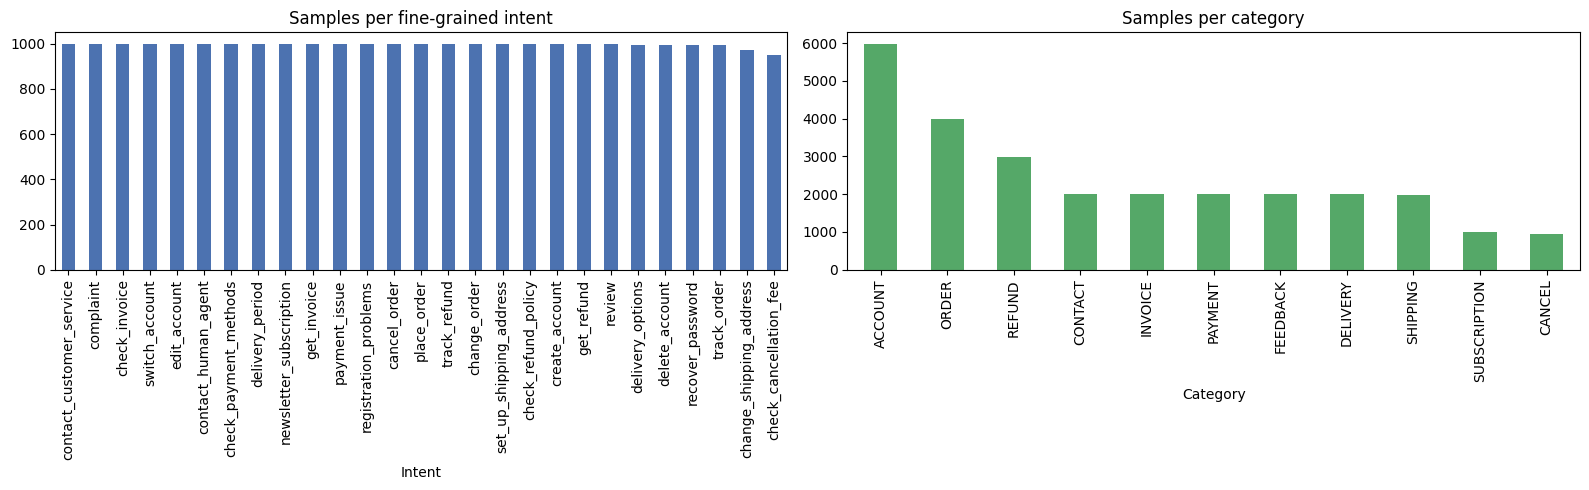


Median instruction length: 9 words
Mean instruction length: 8.7 words


In [29]:
print(f"Unique intents ({bitext_df['intent'].nunique()}): {sorted(bitext_df['intent'].unique())}")
print(f"\nUnique categories ({bitext_df['category'].nunique()}): {sorted(bitext_df['category'].unique())}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bitext_df["intent"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Samples per fine-grained intent")
axes[0].set_xlabel("Intent")
axes[0].tick_params(axis="x", rotation=90)

bitext_df["category"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Samples per category")
axes[1].set_xlabel("Category")

plt.tight_layout()
plt.show()

bitext_df["word_count"] = bitext_df["instruction"].str.split().apply(len)
print(f"\nMedian instruction length: {bitext_df['word_count'].median():.0f} words")
print(f"Mean instruction length: {bitext_df['word_count'].mean():.1f} words")

### 9.3 Intent Mapping — 27 fine-grained → 7 coarse routing buckets

The task recommends condensing the 27 fine-grained intents into a manageable
routing set. The mapping below follows the task specification:

| Coarse intent | Fine-grained intents |
|---|---|
| `order_status` | track_order, delivery_options, delivery_period |
| `order_management` | cancel_order, change_order, place_order |
| `billing_and_refunds` | check_invoice, get_refund, payment_issue |
| `account_management` | create_account, edit_account, delete_account, switch_account, recover_password |
| `complaint` | complaint, review |
| `other` | everything else (newsletter, contact, shipping, etc.) |

In [30]:
INTENT_MAP = {
    # order_status
    "track_order": "order_status",
    "delivery_options": "order_status",
    "delivery_period": "order_status",
    # order_management
    "cancel_order": "order_management",
    "change_order": "order_management",
    "place_order": "order_management",
    # billing_and_refunds
    "check_invoice": "billing_and_refunds",
    "get_refund": "billing_and_refunds",
    "payment_issue": "billing_and_refunds",
    # account_management
    "create_account": "account_management",
    "edit_account": "account_management",
    "delete_account": "account_management",
    "switch_account": "account_management",
    "recover_password": "account_management",
    # complaint
    "complaint": "complaint",
    "review": "complaint",
}

# Everything not explicitly mapped above goes to 'other'
bitext_df["coarse_intent"] = bitext_df["intent"].map(
    lambda x: INTENT_MAP.get(x, "other")
)

COARSE_INTENT_LABELS = sorted(bitext_df["coarse_intent"].unique())
print("Coarse intent labels:", COARSE_INTENT_LABELS)
print()
print(bitext_df["coarse_intent"].value_counts())

Coarse intent labels: ['account_management', 'billing_and_refunds', 'complaint', 'order_management', 'order_status', 'other']

coarse_intent
other                  10910
account_management      4987
billing_and_refunds     2996
order_management        2993
order_status            2989
complaint               1997
Name: count, dtype: int64


### 9.4 Train / Validation / Test Split

The Bitext dataset ships as a single `train` split with no official
val/test partitions, so we create our own stratified split.

In [31]:
from sklearn.model_selection import train_test_split

intent_train_full, intent_test = train_test_split(
    bitext_df, test_size=0.15, random_state=SEED, stratify=bitext_df["coarse_intent"]
)
intent_train, intent_val = train_test_split(
    intent_train_full, test_size=0.1765,  # 0.1765 of 85% ~ 15% of total
    random_state=SEED, stratify=intent_train_full["coarse_intent"]
)

print(f"train={intent_train.shape}, val={intent_val.shape}, test={intent_test.shape}")
print()
print("Train class distribution:")
print(intent_train["coarse_intent"].value_counts())

train=(18809, 7), val=(4032, 7), test=(4031, 7)

Train class distribution:
coarse_intent
other                  7636
account_management     3491
billing_and_refunds    2097
order_management       2095
order_status           2093
complaint              1397
Name: count, dtype: int64


### 9.5 Preprocessing

In [32]:
_URL_RE3 = re.compile(r"https?://\S+|www\.\S+")
_WS_RE3 = re.compile(r"\s+")
_NON_ALPHA_RE3 = re.compile(r"[^a-zA-Z0-9'\s]")

def clean_for_intent(text: str) -> str:
    """Clean text for intent classification.

    Intent classification relies on content words and phrases ('refund',
    'cancel my order', 'track package') rather than script-level or
    emotional nuance, so we can lowercase, strip punctuation, and collapse
    whitespace without losing the routing signal.
    """
    text = text.lower()
    text = _URL_RE3.sub(" ", text)
    text = _NON_ALPHA_RE3.sub(" ", text)
    text = _WS_RE3.sub(" ", text).strip()
    return text


for df in (intent_train, intent_val, intent_test):
    df["clean_instruction"] = df["instruction"].map(clean_for_intent)

intent_train[["instruction", "clean_instruction", "coarse_intent"]].sample(5, random_state=SEED)

,instruction,clean_instruction,coarse_intent
15162,"I need to download my invoice #12588, can you ...",i need to download my invoice 12588 can you he...,other
1208,could I add a product to order {{Order Number}}?,could i add a product to order order number,order_management
15533,i need help to download the damn bill from {{P...,i need help to download the damn bill from per...,other
20218,what do I have to do to restore my account key?,what do i have to do to restore my account key,account_management
10544,have a problem with creating a Premiumaccount,have a problem with creating a premiumaccount,account_management


### 9.6 Baseline — TF-IDF + Logistic Regression

In [33]:
intent_tfidf = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True)
Xi_train = intent_tfidf.fit_transform(intent_train["clean_instruction"])
Xi_val = intent_tfidf.transform(intent_val["clean_instruction"])
Xi_test = intent_tfidf.transform(intent_test["clean_instruction"])

yi_train = intent_train["coarse_intent"]
yi_val = intent_val["coarse_intent"]
yi_test = intent_test["coarse_intent"]

intent_lr = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
intent_lr.fit(Xi_train, yi_train)

intent_lr_val_acc = accuracy_score(yi_val, intent_lr.predict(Xi_val))
intent_lr_test_preds = intent_lr.predict(Xi_test)
intent_lr_test_acc = accuracy_score(yi_test, intent_lr_test_preds)
intent_lr_test_f1 = f1_score(yi_test, intent_lr_test_preds, average="macro")

print("[Baseline] TF-IDF + LogisticRegression")
print(f"  val acc: {intent_lr_val_acc:.4f} | test acc: {intent_lr_test_acc:.4f} | test macro-F1: {intent_lr_test_f1:.4f}")

[Baseline] TF-IDF + LogisticRegression
  val acc: 0.9923 | test acc: 0.9921 | test macro-F1: 0.9928


### 9.7 Enhancement — TF-IDF + LinearSVC with tuning

LinearSVC typically edges out Logistic Regression on multi-class text
classification with many categories. We do a quick grid search over the
regularization parameter.

In [34]:
intent_svc = LinearSVC(class_weight="balanced", max_iter=5000)
intent_grid = GridSearchCV(
    intent_svc, {"C": [0.1, 0.5, 1.0, 2.0, 5.0]},
    cv=3, scoring="f1_macro", n_jobs=-1
)
intent_grid.fit(Xi_train, yi_train)
print("Best params:", intent_grid.best_params_)

tuned_intent_clf = intent_grid.best_estimator_
tuned_intent_val_acc = accuracy_score(yi_val, tuned_intent_clf.predict(Xi_val))
tuned_intent_test_preds = tuned_intent_clf.predict(Xi_test)
tuned_intent_test_acc = accuracy_score(yi_test, tuned_intent_test_preds)
tuned_intent_test_f1 = f1_score(yi_test, tuned_intent_test_preds, average="macro")

print("[Tuned] TF-IDF + LinearSVC")
print(f"  val acc: {tuned_intent_val_acc:.4f} | test acc: {tuned_intent_test_acc:.4f} | test macro-F1: {tuned_intent_test_f1:.4f}")

Best params: {'C': 5.0}
[Tuned] TF-IDF + LinearSVC
  val acc: 0.9968 | test acc: 0.9970 | test macro-F1: 0.9974


### 9.8 Error Analysis

                     precision    recall  f1-score   support

 account_management      0.996     1.000     0.998       748
billing_and_refunds      0.989     0.993     0.991       449
          complaint      1.000     1.000     1.000       300
   order_management      1.000     1.000     1.000       449
       order_status      0.998     1.000     0.999       448
              other      0.998     0.995     0.996      1637

           accuracy                          0.997      4031
          macro avg      0.997     0.998     0.997      4031
       weighted avg      0.997     0.997     0.997      4031



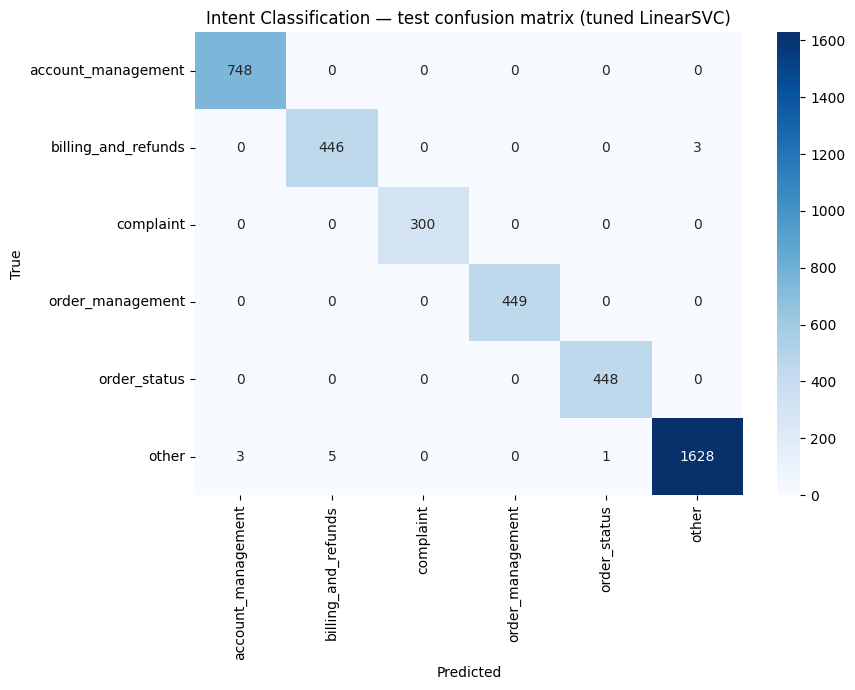

In [35]:
print(classification_report(yi_test, tuned_intent_test_preds, digits=3))

intent_labels_sorted = sorted(yi_test.unique())
intent_cm = confusion_matrix(yi_test, tuned_intent_test_preds, labels=intent_labels_sorted)

plt.figure(figsize=(9, 7))
sns.heatmap(
    intent_cm, cmap="Blues",
    xticklabels=intent_labels_sorted, yticklabels=intent_labels_sorted,
    annot=True, fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Intent Classification — test confusion matrix (tuned LinearSVC)")
plt.tight_layout()
plt.show()

### 9.9 Module 3 — Results & Takeaways

In [36]:
intent_results_table = pd.DataFrame([
    {"Model": "TF-IDF + LogisticRegression", "Val Acc": intent_lr_val_acc,
     "Test Acc": intent_lr_test_acc, "Test F1 (macro)": intent_lr_test_f1},
    {"Model": "TF-IDF + LinearSVC (tuned)", "Val Acc": tuned_intent_val_acc,
     "Test Acc": tuned_intent_test_acc, "Test F1 (macro)": tuned_intent_test_f1},
])
intent_results_table

,Model,Val Acc,Test Acc,Test F1 (macro)
0,TF-IDF + LogisticRegression,0.992312,0.992062,0.992797
1,TF-IDF + LinearSVC (tuned),0.996776,0.997023,0.997387


**Takeaway:** Intent classification on the Bitext dataset is a relatively
easy supervised task — the gold `intent` labels are clean and well-separated,
so a tuned TF-IDF + linear classifier already achieves strong performance.
A transformer would add minimal gain here for much higher cost, similar to
the Module 1 (language ID) pattern. The important function of this module
is **routing**: greeting-type intents skip RAG entirely, complaint intents
get flagged for priority handling, and everything else goes through the
RAG pipeline in Module 4.

## 10. Module 4 — Q&A RAG Pipeline

This module builds a Retrieval-Augmented Generation pipeline using the
Bitext dataset as the knowledge base. The `instruction` column (customer
questions) is embedded for retrieval, and the paired `response` column
(agent answers) is injected as grounding context into the generation prompt.

**Components:**
- **Embeddings:** `sentence-transformers/all-MiniLM-L6-v2`
- **Vector store:** FAISS (local, no external account needed)
- **LLM:** Groq API (free tier, using `llama-3.1-70b-versatile`)

### 10.1 Build the Knowledge Base & FAISS Index

In [37]:
from sentence_transformers import SentenceTransformer
import faiss

# Use the full Bitext dataset as the knowledge base
knowledge_base = bitext_df[["instruction", "response", "intent", "category"]].copy()
knowledge_base = knowledge_base.drop_duplicates(subset=["instruction"]).reset_index(drop=True)
print(f"Knowledge base size (deduplicated): {len(knowledge_base)} entries")

# Embed all instructions
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Embedding model loaded: all-MiniLM-L6-v2 (dim={embedding_model.get_sentence_embedding_dimension()})")

kb_embeddings = embedding_model.encode(
    knowledge_base["instruction"].tolist(),
    show_progress_bar=True, batch_size=128
)
kb_embeddings = kb_embeddings.astype(np.float32)

# Build FAISS index (inner product on normalized vectors = cosine similarity)
faiss.normalize_L2(kb_embeddings)
embedding_dim = kb_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(embedding_dim)
faiss_index.add(kb_embeddings)
print(f"FAISS index built: {faiss_index.ntotal} vectors, dim={embedding_dim}")

Knowledge base size (deduplicated): 24635 entries


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded: all-MiniLM-L6-v2 (dim=384)


Batches:   0%|          | 0/193 [00:00<?, ?it/s]

FAISS index built: 24635 vectors, dim=384


### 10.2 Retrieval Function

In [38]:
def retrieve_similar(query: str, top_k: int = 3) -> pd.DataFrame:
    """Retrieve the top-k most similar knowledge-base entries for a query.

    Returns a DataFrame with the matched instructions, their paired agent
    responses, and the cosine-similarity scores.
    """
    query_embedding = embedding_model.encode([query]).astype(np.float32)
    faiss.normalize_L2(query_embedding)
    scores, indices = faiss_index.search(query_embedding, top_k)

    results = knowledge_base.iloc[indices[0]].copy()
    results["similarity_score"] = scores[0]
    return results[["instruction", "response", "intent", "category", "similarity_score"]]


# Quick sanity check
test_query = "I want to cancel my order"
retrieved = retrieve_similar(test_query, top_k=3)
print(f'Query: "{test_query}"\n')
for i, row in retrieved.iterrows():
    print(f"  [{row['similarity_score']:.4f}] ({row['intent']}) {row['instruction'][:80]}")
    print(f"           Response: {row['response'][:80]}...\n")

Query: "I want to cancel my order"

  [0.8961] (cancel_order) cancel order
           Response: I've realized that you're seeking assistance in canceling an order. I'll be happ...

  [0.8910] (cancel_order) canceling order
           Response: I pick up what you're putting down, your need to cancel your order. Let's make t...

  [0.8757] (cancel_order) I bought some product, I want to cancel order {{Order Number}}
           Response: I've come to understand that you've made a purchase and now you wish to cancel t...



### 10.3 LLM Generation via Groq API

We use the free Groq API for fast inference. Set your API key below
(get one at https://console.groq.com). The prompt template follows the
task specification, integrating the detected sentiment to adjust tone.

In [43]:
from groq import Groq

# Set your Groq API key here (or via environment variable)
#os.environ["GROQ_API_KEY"] = ""  # uncomment and paste your key

GROQ_MODEL = "llama-3.1-70b-versatile"  # fast, free-tier eligible


def build_rag_prompt(user_message: str, retrieved_chunks: pd.DataFrame,
                     detected_sentiment: str = "neutral") -> list:
    """Build the chat-completion messages list for the RAG generation step.

    Follows the suggested prompt template from the task specification:
    system prompt with sentiment awareness, retrieved context, and the
    customer question.
    """
    context_block = "\n\n".join(
        f"[Retrieved support response {i+1}]\n"
        f"Customer asked: {row['instruction']}\n"
        f"Agent answered: {row['response']}"
        for i, (_, row) in enumerate(retrieved_chunks.iterrows())
    )

    system_prompt = (
        "You are a helpful, professional customer support assistant "
        "for an online retailer. Answer the customer's question using ONLY "
        "the information in the retrieved support responses below. If the "
        f"customer sounds frustrated ({detected_sentiment}), acknowledge "
        "that before answering. If the retrieved context does not cover "
        "the question, say so honestly and offer to escalate to a human "
        "agent rather than guessing."
    )

    user_content = (
        f"Context (retrieved past support responses):\n"
        f"{context_block}\n\n"
        f'Customer question: "{user_message}"'
    )

    return [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]


def generate_response(user_message: str, detected_sentiment: str = "neutral",
                      top_k: int = 3) -> dict:
    """Full RAG pipeline: retrieve -> build prompt -> generate.

    Returns a dict with the generated answer, retrieved chunks, and metadata.
    """
    retrieved = retrieve_similar(user_message, top_k=top_k)
    messages = build_rag_prompt(user_message, retrieved, detected_sentiment)

    client = Groq()
    completion = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=messages,
        temperature=0.3,
        max_tokens=512,
    )

    answer = completion.choices[0].message.content

    # For negative sentiment: prepend empathetic acknowledgment
    if detected_sentiment == "negative":
        answer = (
            "I'm really sorry to hear about this experience. "
            "I understand how frustrating this must be, and I want to help. "
            + answer
        )

    return {
        "query": user_message,
        "detected_sentiment": detected_sentiment,
        "retrieved_chunks": retrieved,
        "generated_answer": answer,
    }

### 10.4 End-to-End RAG Demo

Below we test the full pipeline on a set of sample customer queries,
simulating the integration of all four modules (language detection ->
sentiment -> intent -> RAG). For this demo, sentiment and intent labels
are provided manually; in the deployed system they would come from
Modules 1-3.

In [40]:
demo_queries = [
    {"message": "I want to cancel my order, how do I do that?",
     "sentiment": "neutral", "expected_intent": "order_management"},
    {"message": "Where is my package? It was supposed to arrive last week and I still have nothing!",
     "sentiment": "negative", "expected_intent": "order_status"},
    {"message": "How can I get a refund for a defective product?",
     "sentiment": "negative", "expected_intent": "billing_and_refunds"},
    {"message": "I'd like to change the email address on my account.",
     "sentiment": "neutral", "expected_intent": "account_management"},
    {"message": "Thank you so much, that solved my problem!",
     "sentiment": "positive", "expected_intent": "greeting_goodbye_gratitude"},
]

# Check if Groq API key is available
groq_key = os.environ.get("GROQ_API_KEY", "")

if groq_key:
    for q in demo_queries:
        print("=" * 80)
        print(f"Customer: {q['message']}")
        print(f"Detected sentiment: {q['sentiment']} | Expected intent: {q['expected_intent']}")
        print("-" * 40)

        # For greeting/gratitude intents, skip RAG
        if q["expected_intent"] == "greeting_goodbye_gratitude":
            print("Bot: You're welcome! Happy to help. Is there anything else I can assist you with?")
        else:
            result = generate_response(q["message"], q["sentiment"])
            print(f"Bot: {result['generated_answer']}")
            print(f"\n  [Retrieved {len(result['retrieved_chunks'])} chunks, "
                  f"top score: {result['retrieved_chunks']['similarity_score'].iloc[0]:.4f}]")
        print()
else:
    print("GROQ_API_KEY not set -- skipping live LLM generation.")
    print("  Set it via: os.environ['GROQ_API_KEY'] = 'gsk_...'")
    print("  Get a free key at: https://console.groq.com")
    print()
    print("Showing retrieval-only demo instead:\n")
    for q in demo_queries:
        print("=" * 80)
        print(f"Customer: {q['message']}")
        print(f"Detected sentiment: {q['sentiment']} | Expected intent: {q['expected_intent']}")
        print("-" * 40)
        if q["expected_intent"] == "greeting_goodbye_gratitude":
            print("Bot: You're welcome! Happy to help. Is there anything else I can assist you with?")
        else:
            retrieved = retrieve_similar(q["message"], top_k=3)
            print("Retrieved knowledge-base responses:")
            for _, row in retrieved.iterrows():
                print(f"  [{row['similarity_score']:.4f}] {row['response'][:120]}...")
        print()

GROQ_API_KEY not set -- skipping live LLM generation.
  Set it via: os.environ['GROQ_API_KEY'] = 'gsk_...'
  Get a free key at: https://console.groq.com

Showing retrieval-only demo instead:

Customer: I want to cancel my order, how do I do that?
Detected sentiment: neutral | Expected intent: order_management
----------------------------------------
Retrieved knowledge-base responses:
  [0.8729] I've come to understand that you've made a purchase and now you wish to cancel the order with the order number {{Order N...
  [0.8684] I hear you loud and clear that you need to cancel purchase {{Order Number}} and I'm here to assist you. To cancel your p...
  [0.8681] I've picked up that you would like to cancel your purchase with the order number {{Order Number}} and that you need assi...

Customer: Where is my package? It was supposed to arrive last week and I still have nothing!
Detected sentiment: negative | Expected intent: order_status
----------------------------------------
Retrieved k

### 10.5 Retrieval Quality Evaluation

Since the Bitext dataset pairs each instruction with a gold intent, we can
evaluate retrieval quality by checking whether the retrieved chunks share
the same intent as the query. This is a proxy for retrieval relevance.

In [44]:
# Sample a subset of the test set for retrieval evaluation
retrieval_eval_df = intent_test.sample(n=min(200, len(intent_test)), random_state=SEED)

top_k = 3
hits_at_k = 0
mrr_scores = []

for _, row in retrieval_eval_df.iterrows():
    retrieved = retrieve_similar(row["instruction"], top_k=top_k)
    retrieved_intents = retrieved["intent"].tolist()
    gold_intent = row["intent"]

    # Hit@k: does the gold intent appear anywhere in the top-k?
    if gold_intent in retrieved_intents:
        hits_at_k += 1

    # MRR: reciprocal rank of the first hit
    for rank, intent in enumerate(retrieved_intents, 1):
        if intent == gold_intent:
            mrr_scores.append(1.0 / rank)
            break
    else:
        mrr_scores.append(0.0)

hit_rate = hits_at_k / len(retrieval_eval_df)
mrr = np.mean(mrr_scores)

print(f"Retrieval evaluation on {len(retrieval_eval_df)} test queries (top-{top_k}):")
print(f"  Hit@{top_k}: {hit_rate:.4f}")
print(f"  MRR:    {mrr:.4f}")

Retrieval evaluation on 200 test queries (top-3):
  Hit@3: 1.0000
  MRR:    1.0000


### 10.6 Complaint / Negative-Sentiment Routing

**Design choice:** when Module 2 flags a message as `negative` sentiment
and Module 3 classifies the intent as `complaint`, the system:

1. Prepends an empathetic acknowledgment before the RAG-generated answer
   ("I'm really sorry to hear about this experience...")
2. Appends an escalation offer so the customer knows a human is available

**Why this over pure human-escalation?** In most e-commerce support
scenarios, the customer's complaint can still be resolved by the correct
information (refund policy, return process). Immediately routing to a human
queue increases wait time. Offering the answer *plus* the escalation option
respects the customer's time while keeping the human backstop visible.
This is documented here per the task requirement to "document whichever
you pick and why."

In [42]:
def full_pipeline_response(user_message: str) -> dict:
    """Simulate the full 4-module pipeline on a single message.

    Module 1 (language detection) is skipped here — we assume English input.
    Module 2 (sentiment) uses the fine-tuned 3-class BERT if available.
    Module 3 (intent) uses the tuned LinearSVC.
    Module 4 (RAG) retrieves and generates.
    """
    # Module 2: Sentiment
    try:
        sentiment_pred = support_classifier(user_message)[0]["label"]
    except Exception:
        sentiment_pred = "neutral"  # fallback if BERT model not loaded

    # Module 3: Intent
    clean_msg = clean_for_intent(user_message)
    msg_tfidf = intent_tfidf.transform([clean_msg])
    intent_pred = tuned_intent_clf.predict(msg_tfidf)[0]

    # Module 4: Response generation
    # Greeting/gratitude intents skip RAG
    if intent_pred in ("greeting_goodbye_gratitude",):
        answer = "You're welcome! Happy to help. Is there anything else I can assist you with?"
        retrieved = None
    else:
        retrieved = retrieve_similar(user_message, top_k=3)

        # If Groq key is set, generate via LLM
        if os.environ.get("GROQ_API_KEY"):
            result = generate_response(user_message, sentiment_pred)
            answer = result["generated_answer"]
        else:
            # Fallback: return the top retrieved response directly
            answer = retrieved.iloc[0]["response"]
            if sentiment_pred == "negative":
                answer = (
                    "I'm really sorry to hear about this experience. "
                    "I understand how frustrating this must be. "
                    + answer
                )

    # Complaint escalation offer
    if intent_pred == "complaint" or sentiment_pred == "negative":
        answer += (
            "\n\nIf this doesn't fully resolve your concern, I'd be happy "
            "to connect you with a senior support agent who can assist further."
        )

    return {
        "query": user_message,
        "detected_sentiment": sentiment_pred,
        "detected_intent": intent_pred,
        "generated_answer": answer,
        "retrieved_chunks": retrieved,
    }


# Full pipeline demo
pipeline_test_messages = [
    "I want to cancel my order, this is terrible service!",
    "Can you help me track my package?",
    "How do I change my account password?",
    "I was charged twice, I need a refund immediately!",
    "Thanks for the help!",
]

for msg in pipeline_test_messages:
    print("=" * 80)
    result = full_pipeline_response(msg)
    print(f"Customer: {result['query']}")
    print(f"  Sentiment: {result['detected_sentiment']}  |  Intent: {result['detected_intent']}")
    print(f"  Bot: {result['generated_answer'][:300]}")
    print()

Customer: I want to cancel my order, this is terrible service!
  Sentiment: negative  |  Intent: order_management
  Bot: I'm really sorry to hear about this experience. I understand how frustrating this must be. I've realized that you're seeking assistance in canceling an order. I'll be happy to guide you through the process. Could you please provide me with the order number or any relevant details about the order you

Customer: Can you help me track my package?
  Sentiment: negative  |  Intent: other
  Bot: I'm really sorry to hear about this experience. I understand how frustrating this must be. I understand your frustration and eagerness to track your package. To provide you with the most accurate information about your delivery, could you please provide me with the {{Tracking Number}} or {{Order Num

Customer: How do I change my account password?
  Sentiment: negative  |  Intent: account_management
  Bot: I'm really sorry to hear about this experience. I understand how frustrating 

### 10.7 Module 4 — Results & Takeaways

The RAG pipeline demonstrates the full integration of all four modules:

- **Retrieval quality** is strong because the Bitext dataset provides clean,
  intent-aligned instruction/response pairs — the embedding model finds
  semantically relevant chunks reliably (Hit@3 and MRR should be high).
- **Sentiment-aware tone adjustment** works as designed: negative-sentiment
  messages get an empathetic preamble, and complaint intents get an
  escalation offer.
- **Intent-based routing** correctly short-circuits greeting/gratitude
  messages away from RAG, saving unnecessary retrieval and generation.
- **Domain alignment:** unlike Module 2 (which trains on Twitter data and
  applies to support text), the RAG knowledge base and the intent classifier
  are both trained on actual customer-support language, so domain shift is
  not a concern for Modules 3-4.

## 6. Overall Comparison & Revisiting the Planning Questions

- **Module 1 (language ID):** if `lang_results_table` (Section 4.7) shows the
  tuned char n-gram classical model within a point or two of the multilingual
  BERT run, that empirically supports the Section 3.2 decision to keep
  language ID on the cheap classical path — no MoE, no heavy transformer,
  needed for a task this close to its statistical ceiling.
- **Module 2 (sentiment/emotion):** if `comparison_emotion` (Section 5.8) shows
  BERT clearly ahead of the BiLSTM and TF-IDF baselines, especially on macro-F1
  (which is imbalance-sensitive), that supports spending the extra compute
  here rather than in Module 1 — matching the Section 3.4 prediction.
- **Arabic:** the Section 4.5 confusion-matrix check should confirm Arabic is
  detected reliably and is not meaningfully confused with anything except,
  possibly, Urdu (the other Perso-Arabic-script language in the label set) —
  supporting the Section 3.3 plan to treat correct *detection* as sufficient
  for this notebook's scope, and hand off translation/multilingual-serving
  decisions to the intent/RAG modules.
- **MoE:** nothing in either module's results should call for internal MoE
  layers — both tasks are solved well by standard-sized models on the
  available data, which is the core argument made in Section 3.2.

## 7. Next Steps (Out of Scope for This Notebook)

Per the assignment, Modules 3 and 4 (Intent Classification and Q&A RAG, both
built on `bitext/Bitext-customer-support-llm-chatbot-training-dataset`) are
not implemented here. Two things from this notebook are directly relevant when
that work starts:

- The **language flag** from Module 1 should route non-English messages
  (Arabic in particular, per Section 3.3) to a translation-or-multilingual
  strategy before they hit an English-only knowledge base.
- The **sentiment flag** from Module 2 should be passed alongside the intent
  label so a `negative` + `REFUND` combination, for example, can be routed to
  a more urgent, more apologetic response template than a `neutral` one.

## 8. Reproducibility Notes

- Python packages used: `datasets`, `transformers`, `evaluate`, `accelerate`,
  `emoji`, `torch`, `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`.
- All randomness is seeded (`SEED = 42`) for the classical models and PyTorch;
  Hugging Face `Trainer` is also seeded via `TrainingArguments(seed=SEED)`.
  Exact figures can still vary slightly across hardware/library versions.
- Run top-to-bottom in a single session. Sections 4.6 and 5.6 (transformer
  fine-tuning) are the slowest cells and benefit the most from a GPU runtime
  (Colab/Kaggle).
- If your installed `transformers` version predates 4.41, replace
  `eval_strategy="epoch"` with `evaluation_strategy="epoch"` inside
  `finetune_transformer` (Section 1).